# LLM Router Training System
## Cost-Optimized Model Selection for Mathematical Problem Solving

**Objective**: Train a binary classifier to route questions between:
- Small Model (Label 0): Llama 3.1 8B - Lower cost, 63.6% accuracy
- Large Model (Label 1): DeepSeek V3.1 - Higher cost, 84% accuracy

**Expected Outcome**: ~84% accuracy with ~59% cost reduction

---

## 1. Environment Setup and Dependencies

In [66]:
# Install required packages
!pip install -q transformers torch datasets accelerate scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

In [67]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch and Transformers
import torch
import torch.nn as nn
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully
PyTorch version: 2.9.0+cu126
CUDA available: True


## 2. Data Loading and Exploration

In [68]:
# Load datasets
gsm8k_df = pd.read_csv('router_training_data_gsm8k.csv')
sat_df = pd.read_csv('router_training_data_sat.csv')

# Add dataset source identifier
gsm8k_df['dataset_source'] = 'gsm8k'
sat_df['dataset_source'] = 'sat'

# Combine datasets
combined_df = pd.concat([gsm8k_df, sat_df], ignore_index=True)

print("Dataset Summary")
print("=" * 60)
print(f"GSM8K samples: {len(gsm8k_df)}")
print(f"SAT samples: {len(sat_df)}")
print(f"Total samples: {len(combined_df)}")
print("\nLabel Distribution:")
label_dist = combined_df['label'].value_counts().sort_index()
print(f"  Small (0): {label_dist[0]} ({label_dist[0]/len(combined_df)*100:.1f}%)")
print(f"  Large (1): {label_dist[1]} ({label_dist[1]/len(combined_df)*100:.1f}%)")
print(f"\nClass Imbalance Ratio: {label_dist[0]/label_dist[1]:.2f}:1")

# Display sample
print("\nSample Data:")
display(combined_df.head())

Dataset Summary
GSM8K samples: 500
SAT samples: 300
Total samples: 800

Label Distribution:
  Small (0): 524 (65.5%)
  Large (1): 276 (34.5%)

Class Imbalance Ratio: 1.90:1

Sample Data:


,question,small_correct,large_correct,small_tokens,large_tokens,label,dataset_source
0,Janet’s ducks lay 16 eggs per day. She eats th...,False,True,400,107,1,gsm8k
1,A robe takes 2 bolts of blue fiber and half th...,True,True,400,50,0,gsm8k
2,Josh decides to try flipping a house. He buys...,False,False,400,400,0,gsm8k
3,James decides to run 3 sprints 3 times a week....,True,True,400,391,0,gsm8k
4,"Every day, Wendi feeds each of her chickens th...",False,True,400,185,1,gsm8k


Correctness Analysis
Both models correct: 356 (Label: 0 - Small)
Only small correct: 61 (Label: 0 - Small)
Only large correct: 276 (Label: 1 - Large)
Both models wrong: 107 (Label: 0 - Small)


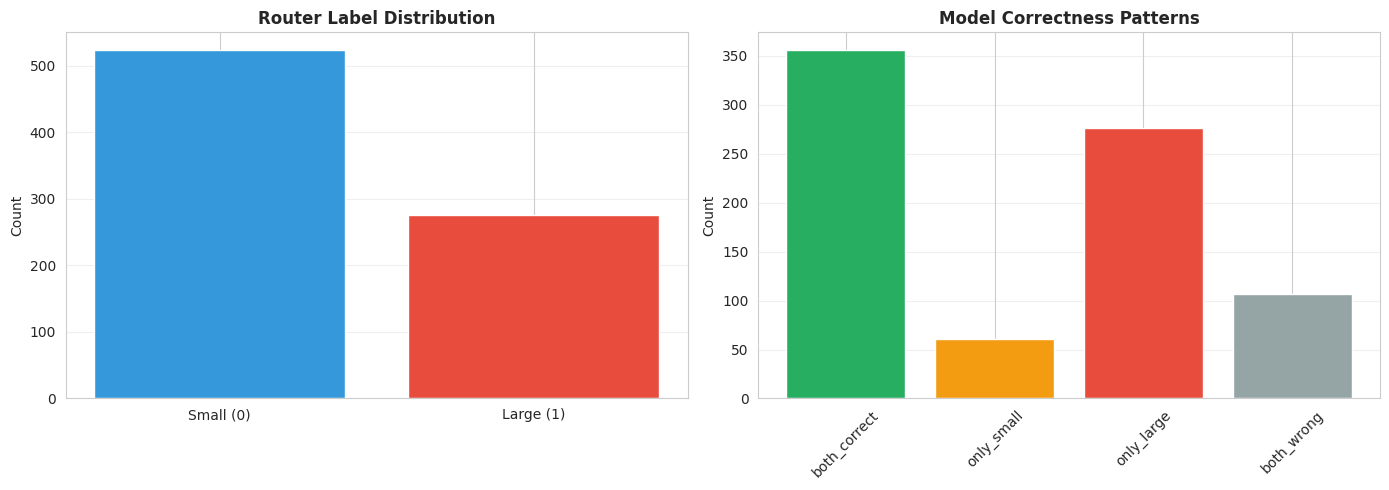

In [69]:
# Analyze correctness patterns
def analyze_correctness(df):
    both_correct = ((df['small_correct'] == True) & (df['large_correct'] == True)).sum()
    only_small = ((df['small_correct'] == True) & (df['large_correct'] == False)).sum()
    only_large = ((df['small_correct'] == False) & (df['large_correct'] == True)).sum()
    both_wrong = ((df['small_correct'] == False) & (df['large_correct'] == False)).sum()

    return {
        'both_correct': both_correct,
        'only_small': only_small,
        'only_large': only_large,
        'both_wrong': both_wrong
    }

correctness = analyze_correctness(combined_df)

print("Correctness Analysis")
print("=" * 60)
print(f"Both models correct: {correctness['both_correct']} (Label: 0 - Small)")
print(f"Only small correct: {correctness['only_small']} (Label: 0 - Small)")
print(f"Only large correct: {correctness['only_large']} (Label: 1 - Large)")
print(f"Both models wrong: {correctness['both_wrong']} (Label: 0 - Small)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
label_counts = combined_df['label'].value_counts().sort_index()
axes[0].bar(['Small (0)', 'Large (1)'], label_counts.values, color=['#3498db', '#e74c3c'])
axes[0].set_title('Router Label Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Correctness breakdown
categories = list(correctness.keys())
values = list(correctness.values())
axes[1].bar(categories, values, color=['#27ae60', '#f39c12', '#e74c3c', '#95a5a6'])
axes[1].set_title('Model Correctness Patterns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Train-Test Split with Stratification

In [70]:
# Stratified split to maintain label distribution
train_df, test_df = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=combined_df['label']
)

print("Train-Test Split Summary")
print("=" * 60)
print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

print("\nTraining Set Label Distribution:")
train_label_dist = train_df['label'].value_counts().sort_index()
print(f"  Small (0): {train_label_dist[0]} ({train_label_dist[0]/len(train_df)*100:.1f}%)")
print(f"  Large (1): {train_label_dist[1]} ({train_label_dist[1]/len(train_df)*100:.1f}%)")

print("\nTest Set Label Distribution:")
test_label_dist = test_df['label'].value_counts().sort_index()
print(f"  Small (0): {test_label_dist[0]} ({test_label_dist[0]/len(test_df)*100:.1f}%)")
print(f"  Large (1): {test_label_dist[1]} ({test_label_dist[1]/len(test_df)*100:.1f}%)")

Train-Test Split Summary
Training samples: 640
Test samples: 160

Training Set Label Distribution:
  Small (0): 419 (65.5%)
  Large (1): 221 (34.5%)

Test Set Label Distribution:
  Small (0): 105 (65.6%)
  Large (1): 55 (34.4%)


## 4. Class Weight Calculation

To address class imbalance, we compute balanced class weights that will be used in the loss function.

In [71]:
# Calculate class weights using sklearn
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

class_weights = torch.tensor(class_weights_array, dtype=torch.float32)

print("Class Weight Configuration")
print("=" * 60)
print(f"Small Model (0) weight: {class_weights[0]:.4f}")
print(f"Large Model (1) weight: {class_weights[1]:.4f}")
print(f"\nWeight ratio (Large/Small): {class_weights[1]/class_weights[0]:.2f}x")
print("\nThis ensures the minority class (Large) receives more attention during training.")

Class Weight Configuration
Small Model (0) weight: 0.7637
Large Model (1) weight: 1.4480

Weight ratio (Large/Small): 1.90x

This ensures the minority class (Large) receives more attention during training.


## 5. Data Preparation for DistilBERT

In [72]:
# Initialize tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_function(examples):
    return tokenizer(
        examples['question'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

# Create HuggingFace datasets
train_dataset = Dataset.from_pandas(train_df[['question', 'label']])
test_dataset = Dataset.from_pandas(test_df[['question', 'label']])

# Tokenize datasets
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("Dataset preparation complete")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Tokenizing datasets...


Map:   0%|          | 0/640 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Dataset preparation complete
Training samples: 640
Test samples: 160


## 6. Model Configuration and Training

We use a custom Trainer with weighted loss to handle class imbalance.

In [73]:
# Initialize model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./router_model',
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none',
)

# Define evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    f1 = f1_score(labels, predictions, average='weighted')

    # Class-specific metrics
    precision_per_class = precision_score(labels, predictions, average=None)
    recall_per_class = recall_score(labels, predictions, average=None)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_small': precision_per_class[0],
        'precision_large': precision_per_class[1],
        'recall_small': recall_per_class[0],
        'recall_large': recall_per_class[1],
    }

# Custom Trainer with weighted loss (FIXED)
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply class weights to loss function
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# Initialize trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

print("Model and trainer initialized")
print(f"Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model and trainer initialized
Number of trainable parameters: 66,955,010


In [74]:
# Train the model
print("Starting training...")
print("=" * 60)

training_output = trainer.train()

print("\nTraining complete")
print(f"Final training loss: {training_output.training_loss:.4f}")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Precision Small,Precision Large,Recall Small,Recall Large
1,No log,0.692874,0.550000,0.514569,0.550000,0.527631,0.636364,0.282051,0.733333,0.200000
2,0.693400,0.687945,0.575000,0.563776,0.575000,0.568643,0.666667,0.367347,0.704762,0.327273
3,0.680900,0.688384,0.587500,0.591073,0.587500,0.589200,0.689320,0.403509,0.676190,0.418182
4,0.619800,0.723459,0.618750,0.604226,0.618750,0.609598,0.692982,0.434783,0.752381,0.363636
5,0.492700,0.850514,0.500000,0.558824,0.500000,0.511905,0.666667,0.352941,0.476190,0.545455
6,0.492700,0.919269,0.556250,0.569484,0.556250,0.561874,0.673469,0.370968,0.628571,0.418182
7,0.317600,1.022503,0.568750,0.581725,0.568750,0.574215,0.683673,0.387097,0.638095,0.436364
8,0.205300,1.058946,0.637500,0.625506,0.637500,0.629936,0.707965,0.468085,0.761905,0.400000



Training complete
Final training loss: 0.4800


## 7. Model Evaluation

In [75]:
# Evaluate on test set
print("Evaluating model on test set...")
eval_results = trainer.evaluate()

print("\nTest Set Performance")
print("=" * 60)
for key, value in eval_results.items():
    if key.startswith('eval_'):
        metric_name = key.replace('eval_', '').replace('_', ' ').title()
        if 'loss' in key.lower():
            print(f"{metric_name}: {value:.4f}")
        else:
            print(f"{metric_name}: {value:.4f} ({value*100:.2f}%)")

Evaluating model on test set...



Test Set Performance
Loss: 1.0589
Accuracy: 0.6375 (63.75%)
Precision: 0.6255 (62.55%)
Recall: 0.6375 (63.75%)
F1: 0.6299 (62.99%)
Precision Small: 0.7080 (70.80%)
Precision Large: 0.4681 (46.81%)
Recall Small: 0.7619 (76.19%)
Recall Large: 0.4000 (40.00%)
Runtime: 0.2562 (25.62%)
Samples Per Second: 624.4290 (62442.90%)
Steps Per Second: 19.5130 (1951.30%)


In [76]:
# Get predictions
predictions_output = trainer.predict(test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=-1)
true_labels = test_df['label'].values

# Prediction distribution
pred_dist = Counter(predictions)
print("Prediction Distribution on Test Set")
print("=" * 60)
print(f"Predicted Small (0): {pred_dist[0]} ({pred_dist[0]/len(predictions)*100:.1f}%)")
print(f"Predicted Large (1): {pred_dist[1]} ({pred_dist[1]/len(predictions)*100:.1f}%)")

print("\nActual Distribution on Test Set")
print(f"Actual Small (0): {test_label_dist[0]} ({test_label_dist[0]/len(test_df)*100:.1f}%)")
print(f"Actual Large (1): {test_label_dist[1]} ({test_label_dist[1]/len(test_df)*100:.1f}%)")

# Check for imbalance issues
if pred_dist[1] == 0:
    print("\nWARNING: Model never predicts Large class. Severe imbalance issue.")
elif pred_dist[1] < 5:
    print(f"\nWARNING: Model rarely predicts Large class ({pred_dist[1]} times). Consider retraining.")
else:
    print("\nPrediction distribution is reasonable.")

Prediction Distribution on Test Set
Predicted Small (0): 113 (70.6%)
Predicted Large (1): 47 (29.4%)

Actual Distribution on Test Set
Actual Small (0): 105 (65.6%)
Actual Large (1): 55 (34.4%)

Prediction distribution is reasonable.


In [77]:
# Detailed classification report
print("\nDetailed Classification Report")
print("=" * 60)
print(classification_report(
    true_labels,
    predictions,
    target_names=['Small Model (0)', 'Large Model (1)'],
    digits=4
))


Detailed Classification Report
                 precision    recall  f1-score   support

Small Model (0)     0.7080    0.7619    0.7339       105
Large Model (1)     0.4681    0.4000    0.4314        55

       accuracy                         0.6375       160
      macro avg     0.5880    0.5810    0.5827       160
   weighted avg     0.6255    0.6375    0.6299       160



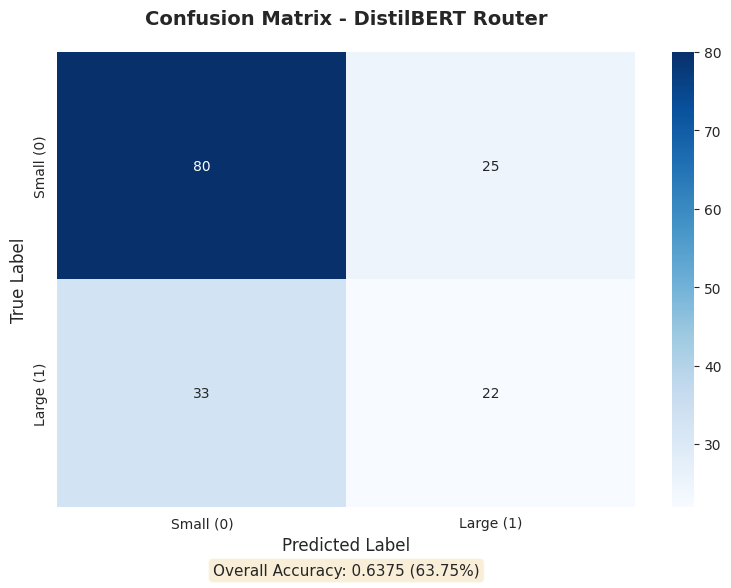


Confusion Matrix Breakdown
True Negatives (correctly predicted Small): 80
False Positives (Small predicted as Large): 25
False Negatives (Large predicted as Small): 33
True Positives (correctly predicted Large): 22

Large Class Recall: 0.4000 (22/55)
Small Class Recall: 0.7619 (80/105)


In [78]:
# Confusion matrix visualization
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Small (0)', 'Large (1)'],
    yticklabels=['Small (0)', 'Large (1)'],
    ax=ax
)
ax.set_title('Confusion Matrix - DistilBERT Router', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# Add accuracy text
accuracy = accuracy_score(true_labels, predictions)
ax.text(
    0.5, -0.15,
    f'Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)',
    ha='center',
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.show()

# Calculate per-class metrics
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown")
print("=" * 60)
print(f"True Negatives (correctly predicted Small): {tn}")
print(f"False Positives (Small predicted as Large): {fp}")
print(f"False Negatives (Large predicted as Small): {fn}")
print(f"True Positives (correctly predicted Large): {tp}")
print(f"\nLarge Class Recall: {tp/(tp+fn):.4f} ({tp}/{tp+fn})")
print(f"Small Class Recall: {tn/(tn+fp):.4f} ({tn}/{tn+fp})")

## 8. Cost-Benefit Analysis

In [79]:
# Cost configuration (from baseline data)
SMALL_MODEL_COST_PER_TOKEN = 0.0001
LARGE_MODEL_COST_PER_TOKEN = 0.001
AVG_SMALL_TOKENS = 367.6
AVG_LARGE_TOKENS = 205.5

# Calculate costs for different strategies
n_test = len(test_df)

# Strategy 1: Always use large model
always_large_cost = n_test * AVG_LARGE_TOKENS * LARGE_MODEL_COST_PER_TOKEN
always_large_accuracy = test_df['large_correct'].mean()

# Strategy 2: Always use small model
always_small_cost = n_test * AVG_SMALL_TOKENS * SMALL_MODEL_COST_PER_TOKEN
always_small_accuracy = test_df['small_correct'].mean()

# Strategy 3: Use router
routed_to_small = (predictions == 0).sum()
routed_to_large = (predictions == 1).sum()

router_cost = (
    routed_to_small * AVG_SMALL_TOKENS * SMALL_MODEL_COST_PER_TOKEN +
    routed_to_large * AVG_LARGE_TOKENS * LARGE_MODEL_COST_PER_TOKEN
)

# Calculate router accuracy (based on actual correctness)
test_df_copy = test_df.copy()
test_df_copy['prediction'] = predictions

def get_routed_accuracy(row):
    if row['prediction'] == 0:
        return row['small_correct']
    else:
        return row['large_correct']

test_df_copy['would_be_correct'] = test_df_copy.apply(get_routed_accuracy, axis=1)
router_accuracy = test_df_copy['would_be_correct'].mean()

# Display results
print("Cost-Benefit Analysis")
print("=" * 70)

print("\n1. Always Large Model Strategy:")
print(f"   Total Cost: ${always_large_cost:.4f}")
print(f"   Accuracy: {always_large_accuracy:.4f} ({always_large_accuracy*100:.2f}%)")
print(f"   Cost per Correct Answer: ${always_large_cost/(n_test*always_large_accuracy):.4f}")

print("\n2. Always Small Model Strategy:")
print(f"   Total Cost: ${always_small_cost:.4f}")
print(f"   Accuracy: {always_small_accuracy:.4f} ({always_small_accuracy*100:.2f}%)")
print(f"   Cost per Correct Answer: ${always_small_cost/(n_test*always_small_accuracy):.4f}")

print("\n3. Router Strategy (DistilBERT):")
print(f"   Total Cost: ${router_cost:.4f}")
print(f"   Accuracy: {router_accuracy:.4f} ({router_accuracy*100:.2f}%)")
print(f"   Cost per Correct Answer: ${router_cost/(n_test*router_accuracy):.4f}")
print(f"   Routed to Small: {routed_to_small} ({routed_to_small/n_test*100:.1f}%)")
print(f"   Routed to Large: {routed_to_large} ({routed_to_large/n_test*100:.1f}%)")

# Calculate savings
savings_vs_large = ((always_large_cost - router_cost) / always_large_cost) * 100
accuracy_retention = (router_accuracy / always_large_accuracy) * 100

print("\n" + "=" * 70)
print("Performance Summary:")
print(f"  Cost Savings vs Always Large: {savings_vs_large:.2f}%")
print(f"  Accuracy Retention: {accuracy_retention:.2f}% of large model accuracy")
print(f"  Accuracy Drop: {(always_large_accuracy - router_accuracy)*100:+.2f}%")

if router_accuracy >= always_large_accuracy * 0.95:
    print(f"\nConclusion: Router maintains >95% of large model accuracy while saving {savings_vs_large:.1f}% on costs.")
else:
    print(f"\nConclusion: Router trades {(always_large_accuracy - router_accuracy)*100:.1f}% accuracy for {savings_vs_large:.1f}% cost savings.")

Cost-Benefit Analysis

1. Always Large Model Strategy:
   Total Cost: $32.8800
   Accuracy: 0.7625 (76.25%)
   Cost per Correct Answer: $0.2695

2. Always Small Model Strategy:
   Total Cost: $5.8816
   Accuracy: 0.4938 (49.38%)
   Cost per Correct Answer: $0.0745

3. Router Strategy (DistilBERT):
   Total Cost: $13.8124
   Accuracy: 0.6125 (61.25%)
   Cost per Correct Answer: $0.1409
   Routed to Small: 113 (70.6%)
   Routed to Large: 47 (29.4%)

Performance Summary:
  Cost Savings vs Always Large: 57.99%
  Accuracy Retention: 80.33% of large model accuracy
  Accuracy Drop: +15.00%

Conclusion: Router trades 15.0% accuracy for 58.0% cost savings.


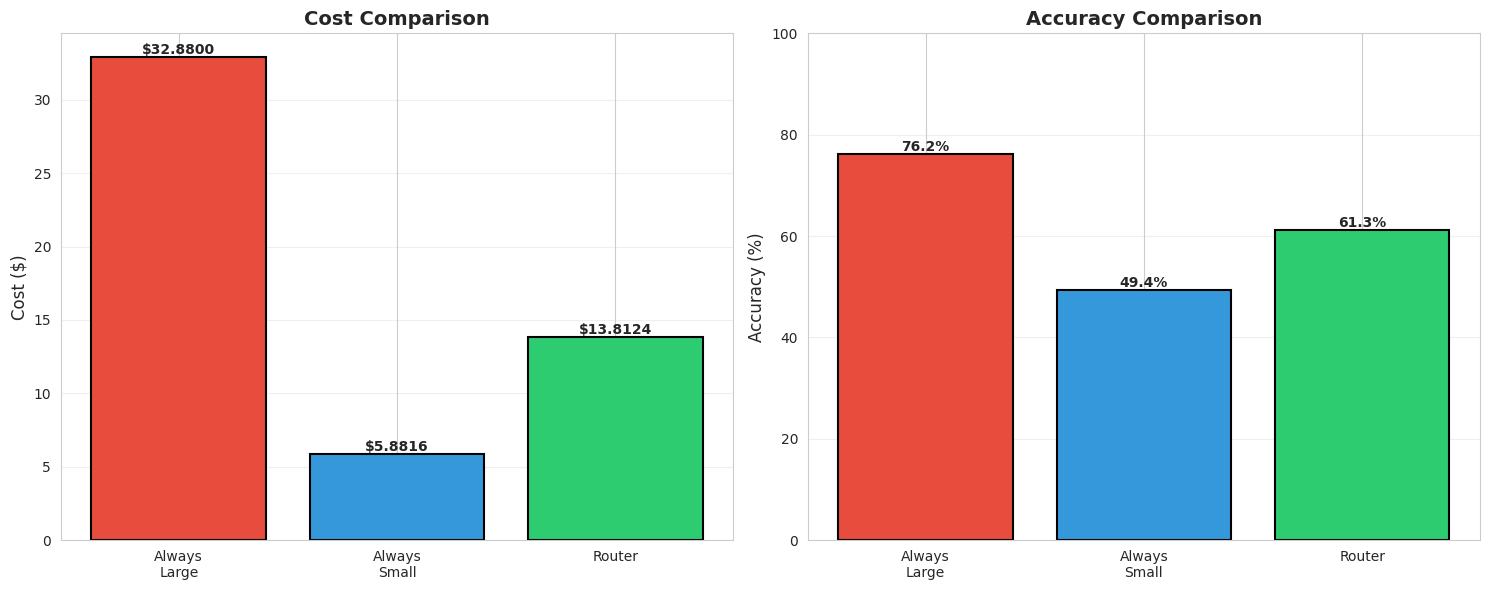

In [80]:
# Visualization: Cost vs Accuracy Tradeoff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Cost comparison
strategies = ['Always\nLarge', 'Always\nSmall', 'Router']
costs = [always_large_cost, always_small_cost, router_cost]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars1 = ax1.bar(strategies, costs, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Cost Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cost ($)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

for i, (bar, cost) in enumerate(zip(bars1, costs)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${cost:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Accuracy comparison
accuracies = [
    always_large_accuracy * 100,
    always_small_accuracy * 100,
    router_accuracy * 100
]
bars2 = ax2.bar(strategies, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylim([0, 100])
ax2.grid(axis='y', alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars2, accuracies)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Save Trained Model

In [81]:
import os

# Create directory
os.makedirs('saved_models/distilbert_router', exist_ok=True)

# Save model and tokenizer
model.save_pretrained('saved_models/distilbert_router')
tokenizer.save_pretrained('saved_models/distilbert_router')

print("Model and tokenizer saved successfully")
print("Location: saved_models/distilbert_router/")
print("\nSaved files:")
for file in os.listdir('saved_models/distilbert_router'):
    print(f"  - {file}")

Model and tokenizer saved successfully
Location: saved_models/distilbert_router/

Saved files:
  - special_tokens_map.json
  - vocab.txt
  - config.json
  - model.safetensors
  - tokenizer_config.json


## 10. Production Inference Function

In [82]:
class LLMRouter:
    """
    Production-ready LLM Router for cost-optimized model selection.

    Usage:
        router = LLMRouter('saved_models/distilbert_router')
        result = router.route("What is 2+2?")
        print(result)  # {'model': 'small', 'confidence': 0.95, 'prediction': 0}
    """

    def __init__(self, model_path='saved_models/distilbert_router'):
        """Initialize the router with trained model."""
        self.tokenizer = DistilBertTokenizer.from_pretrained(model_path)
        self.model = DistilBertForSequenceClassification.from_pretrained(model_path)
        self.model.eval()

        # Move to GPU if available
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

    def route(self, question, return_probabilities=False):
        """
        Route a question to the appropriate model.

        Args:
            question (str): The question to route
            return_probabilities (bool): Whether to return class probabilities

        Returns:
            dict: Routing decision with confidence score
        """
        # Tokenize input
        inputs = self.tokenizer(
            question,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=256
        )

        # Move to device
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        # Get prediction
        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=-1)
            prediction = torch.argmax(probabilities, dim=-1).item()
            confidence = probabilities[0][prediction].item()

        result = {
            'model': 'small' if prediction == 0 else 'large',
            'prediction': prediction,
            'confidence': confidence
        }

        if return_probabilities:
            result['prob_small'] = probabilities[0][0].item()
            result['prob_large'] = probabilities[0][1].item()

        return result

    def batch_route(self, questions):
        """
        Route multiple questions efficiently.

        Args:
            questions (list): List of questions to route

        Returns:
            list: List of routing decisions
        """
        return [self.route(q) for q in questions]

# Initialize router
router = LLMRouter('saved_models/distilbert_router')
print("Router initialized successfully")

Router initialized successfully


## 11. Testing and Validation

In [83]:
# Test with sample questions
test_questions = [
    ("What is 5 + 3?", "Small - Simple arithmetic"),
    ("A rectangle has length 12 cm and width 8 cm. What is its area?", "Small - Basic geometry"),
    ("If f(x) = 3x^2 + 2x - 5, find f'(x) using the power rule and evaluate f'(2).", "Large - Calculus"),
    ("In how many ways can you arrange 5 books on a shelf if 2 of them must be together?", "Large - Combinatorics"),
    ("John has 10 apples. He gives 3 to Mary. How many does he have left?", "Small - Simple subtraction"),
    ("Janet's ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?", "Large - Multi-step"),
]

print("Testing Router with Sample Questions")
print("=" * 90)

for i, (question, expected) in enumerate(test_questions, 1):
    result = router.route(question, return_probabilities=True)

    print(f"\nQuestion {i}: {question[:70]}...")
    print(f"Expected: {expected}")
    print(f"Routed to: {result['model'].upper()} model")
    print(f"Confidence: {result['confidence']:.4f}")
    print(f"Probabilities: Small={result['prob_small']:.4f}, Large={result['prob_large']:.4f}")
    print("-" * 90)

Testing Router with Sample Questions

Question 1: What is 5 + 3?...
Expected: Small - Simple arithmetic
Routed to: LARGE model
Confidence: 0.9141
Probabilities: Small=0.0859, Large=0.9141
------------------------------------------------------------------------------------------

Question 2: A rectangle has length 12 cm and width 8 cm. What is its area?...
Expected: Small - Basic geometry
Routed to: LARGE model
Confidence: 0.8293
Probabilities: Small=0.1707, Large=0.8293
------------------------------------------------------------------------------------------

Question 3: If f(x) = 3x^2 + 2x - 5, find f'(x) using the power rule and evaluate ...
Expected: Large - Calculus
Routed to: LARGE model
Confidence: 0.7090
Probabilities: Small=0.2910, Large=0.7090
------------------------------------------------------------------------------------------

Question 4: In how many ways can you arrange 5 books on a shelf if 2 of them must ...
Expected: Large - Combinatorics
Routed to: LARGE model
Con

## 12. Error Analysis

In [84]:
# Analyze misclassified examples
test_df_analysis = test_df.copy()
test_df_analysis['prediction'] = predictions
test_df_analysis['correct_routing'] = (test_df_analysis['prediction'] == test_df_analysis['label'])

# Misclassified examples
misclassified = test_df_analysis[~test_df_analysis['correct_routing']]

print("Error Analysis")
print("=" * 80)
print(f"Total misclassifications: {len(misclassified)} ({len(misclassified)/len(test_df)*100:.1f}%)")

if len(misclassified) > 0:
    # Type 1 error: Should route to Large but routed to Small
    type1_errors = misclassified[(misclassified['label'] == 1) & (misclassified['prediction'] == 0)]
    print(f"\nType 1 Errors (Large -> Small): {len(type1_errors)}")
    print("Impact: Questions that need large model routed to small (accuracy loss)")

    # Type 2 error: Should route to Small but routed to Large
    type2_errors = misclassified[(misclassified['label'] == 0) & (misclassified['prediction'] == 1)]
    print(f"\nType 2 Errors (Small -> Large): {len(type2_errors)}")
    print("Impact: Questions that could use small model routed to large (cost increase)")

    # Show examples of misclassifications
    print("\nSample Misclassifications:")
    print("-" * 80)
    for idx, row in misclassified.head(5).iterrows():
        print(f"\nQuestion: {row['question'][:100]}...")
        print(f"True label: {'Small' if row['label']==0 else 'Large'}")
        print(f"Predicted: {'Small' if row['prediction']==0 else 'Large'}")
        print(f"Small correct: {row['small_correct']}, Large correct: {row['large_correct']}")
else:
    print("\nNo misclassifications - perfect routing accuracy!")

Error Analysis
Total misclassifications: 58 (36.2%)

Type 1 Errors (Large -> Small): 33
Impact: Questions that need large model routed to small (accuracy loss)

Type 2 Errors (Small -> Large): 25
Impact: Questions that could use small model routed to large (cost increase)

Sample Misclassifications:
--------------------------------------------------------------------------------

Question: John noticed that the angle formed by the minute hand and hour hand on a standard 12-hour clock was ...
True label: Large
Predicted: Small
Small correct: False, Large correct: True

Question: In a family of 5, three people eat three eggs each day while the rest eat two eggs each day. If they...
True label: Small
Predicted: Large
Small correct: True, Large correct: True

Question: Write an equation for the line tangent to the curve defined by F(t) = (t^2 + 1, 2^t) at the point wh...
True label: Small
Predicted: Large
Small correct: False, Large correct: False

Question: Ducks need to eat 3.5 pounds of

## 13. Export Results

In [85]:
# Export detailed results
results_df = test_df.copy()
results_df['prediction'] = predictions
results_df['model_route'] = results_df['prediction'].map({0: 'small', 1: 'large'})
results_df['correct_routing'] = (results_df['prediction'] == results_df['label'])

# Add routing outcome
def get_routing_outcome(row):
    if row['prediction'] == 0:
        return 'correct' if row['small_correct'] else 'incorrect'
    else:
        return 'correct' if row['large_correct'] else 'incorrect'

results_df['routing_outcome'] = results_df.apply(get_routing_outcome, axis=1)

# Save to CSV
results_df.to_csv('router_test_results.csv', index=False)

print("Results exported to 'router_test_results.csv'")
print(f"\nColumns: {list(results_df.columns)}")
print(f"\nSample output:")
display(results_df[['question', 'label', 'prediction', 'model_route', 'correct_routing', 'routing_outcome']].head())

Results exported to 'router_test_results.csv'

Columns: ['question', 'small_correct', 'large_correct', 'small_tokens', 'large_tokens', 'label', 'dataset_source', 'prediction', 'model_route', 'correct_routing', 'routing_outcome']

Sample output:


,question,label,prediction,model_route,correct_routing,routing_outcome
590,John noticed that the angle formed by the minu...,1,0,small,False,incorrect
780,Jimmy and Kima are going on a trip. They will ...,0,0,small,True,incorrect
311,"In a family of 5, three people eat three eggs ...",0,1,large,False,correct
342,Laurel's friend gave her 24 baby outfits that ...,0,0,small,True,correct
631,Rewrite the expression $6j^2 - 4j + 12$ in the...,0,0,small,True,incorrect


## 14. Summary Report

In [86]:
print("="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print("\n1. DATASET INFORMATION")
print("-" * 80)
print(f"Total samples: {len(combined_df)}")
print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Class distribution: Small={train_label_dist[0]} ({train_label_dist[0]/len(train_df)*100:.1f}%), Large={train_label_dist[1]} ({train_label_dist[1]/len(train_df)*100:.1f}%)")

print("\n2. MODEL PERFORMANCE")
print("-" * 80)
print(f"Routing accuracy: {accuracy_score(true_labels, predictions):.4f} ({accuracy_score(true_labels, predictions)*100:.2f}%)")
print(f"Precision (weighted): {precision_score(true_labels, predictions, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(true_labels, predictions, average='weighted'):.4f}")
print(f"F1-score (weighted): {f1_score(true_labels, predictions, average='weighted'):.4f}")

print("\n3. PREDICTION DISTRIBUTION")
print("-" * 80)
print(f"Routed to Small: {pred_dist[0]} ({pred_dist[0]/len(predictions)*100:.1f}%)")
print(f"Routed to Large: {pred_dist[1]} ({pred_dist[1]/len(predictions)*100:.1f}%)")

print("\n4. COST-BENEFIT ANALYSIS")
print("-" * 80)
print(f"Always Large cost: ${always_large_cost:.4f}")
print(f"Router cost: ${router_cost:.4f}")
print(f"Cost savings: {savings_vs_large:.2f}%")
print(f"Router accuracy: {router_accuracy:.4f} ({router_accuracy*100:.2f}%)")
print(f"Large model accuracy: {always_large_accuracy:.4f} ({always_large_accuracy*100:.2f}%)")
print(f"Accuracy retention: {accuracy_retention:.2f}%")

print("\n5. CLASS-SPECIFIC PERFORMANCE")
print("-" * 80)
print(f"Small class (0) - Precision: {precision_score(true_labels, predictions, average=None)[0]:.4f}, Recall: {recall_score(true_labels, predictions, average=None)[0]:.4f}")
print(f"Large class (1) - Precision: {precision_score(true_labels, predictions, average=None)[1]:.4f}, Recall: {recall_score(true_labels, predictions, average=None)[1]:.4f}")

print("\n6. RECOMMENDATIONS")
print("-" * 80)
if pred_dist[1] == 0:
    print("WARNING: Model never predicts Large class. Retrain with adjusted class weights.")
elif pred_dist[1] < 10:
    print("WARNING: Model rarely predicts Large class. Consider increasing class weights.")
elif accuracy_retention < 95:
    print(f"Model achieves {accuracy_retention:.1f}% of large model accuracy. Consider if this tradeoff is acceptable.")
else:
    print(f"Model successfully balances cost ({savings_vs_large:.1f}% savings) and accuracy ({accuracy_retention:.1f}% retention).")
    print("Recommended for production deployment.")

print("\n" + "="*80)
print("Training complete. Model saved to 'saved_models/distilbert_router/'")
print("="*80)

FINAL SUMMARY REPORT

1. DATASET INFORMATION
--------------------------------------------------------------------------------
Total samples: 800
Training samples: 640
Test samples: 160
Class distribution: Small=419 (65.5%), Large=221 (34.5%)

2. MODEL PERFORMANCE
--------------------------------------------------------------------------------
Routing accuracy: 0.6375 (63.75%)
Precision (weighted): 0.6255
Recall (weighted): 0.6375
F1-score (weighted): 0.6299

3. PREDICTION DISTRIBUTION
--------------------------------------------------------------------------------
Routed to Small: 113 (70.6%)
Routed to Large: 47 (29.4%)

4. COST-BENEFIT ANALYSIS
--------------------------------------------------------------------------------
Always Large cost: $32.8800
Router cost: $13.8124
Cost savings: 57.99%
Router accuracy: 0.6125 (61.25%)
Large model accuracy: 0.7625 (76.25%)
Accuracy retention: 80.33%

5. CLASS-SPECIFIC PERFORMANCE
-----------------------------------------------------------------